# **07 Text2SQL 구현하기**

## 학습 내용
1. **파트 1**: 로컬 SQLite DB로 Text2SQL 기본 실습
   - LangChain SQLDatabase 사용법
   - 자연어 → SQL 변환
   - JOIN, GROUP BY, 집계 쿼리
   - SQL Agent 자동화

2. **파트 2**: Supabase PostgreSQL 클라우드 DB
   - PostgreSQL 직접 연결
   - CSV 데이터 업로드
   - 고급 SQL (서브쿼리, 윈도우 함수)

---

# 파트 1: 로컬 SQLite 데이터베이스로 Text2SQL 실습

## 0. 환경 설정

In [39]:
import os
from dotenv import load_dotenv

load_dotenv()

print("=== 환경 변수 확인 ===")

# OpenAI API Key 확인
if os.environ.get("OPENAI_API_KEY"):
    print("✓ OpenAI API Key 설정됨")

=== 환경 변수 확인 ===
✓ OpenAI API Key 설정됨


## 1. 06_csv_to_sqldb.ipynb 에서 생성한 SQLite DB 사용

In [40]:
import sqlite3
import pandas as pd
import os

# database 폴더 확인
os.makedirs("database", exist_ok=True)

# 06번에서 생성한 DB 파일 사용
db_path = "database/cheonan_city.db"

# DB가 이미 존재하는지 확인
if os.path.exists(db_path):
    print(f"✓ 기존 DB 파일 발견: {db_path}")

    # 테이블 확인
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = [row[0] for row in cursor.fetchall()]
    conn.close()

    if tables:
        print(f"   테이블: {', '.join(tables)}")
    else:
        print("   ⚠ 테이블이 없습니다. CSV 데이터를 로드해야 합니다.")
else:
    print(f"DB 파일이 없습니다. 새로 생성합니다: {db_path}\n")

    # CSV 파일 경로
    csv_files = {
        "organizations": "../datasets/organizations.csv",
        "departments": "../datasets/departments.csv",
        "office_floors": "../datasets/office_floors.csv"
    }

    # SQLite 연결
    conn = sqlite3.connect(db_path)

    # CSV → SQLite 테이블 로드 (순서 중요: FK 제약 때문에)
    for table_name, csv_path in csv_files.items():
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df.to_sql(table_name, conn, if_exists="replace", index=False)
            print(f"✓ {table_name}: {len(df)}개 행 로드 완료")
        else:
            print(f"✗ {table_name}: CSV 파일 없음 ({csv_path})")

    conn.close()
    print(f"\n✓ SQLite DB 생성 완료: {db_path}")

✓ 기존 DB 파일 발견: database/cheonan_city.db
   테이블: organizations, departments, office_floors


## 2. LangChain SQLDatabase 연결

In [41]:
from langchain_community.utilities import SQLDatabase

# SQLite 연결
db_url = f"sqlite:///{db_path}"
db = SQLDatabase.from_uri(db_url)

print("=== LangChain SQLDatabase 연결 ===")
print(f"DB: {db_path}")
print(f"\n테이블 목록:")
print(db.get_usable_table_names())
print("\n✓ 연결 성공!")

=== LangChain SQLDatabase 연결 ===
DB: database/cheonan_city.db

테이블 목록:
['departments', 'office_floors', 'organizations']

✓ 연결 성공!


## 3. 테이블 스키마 탐색

In [42]:
# 전체 테이블 정보
print("=== 데이터베이스 스키마 ===")
print(db.table_info)

print("\n" + "="*80 + "\n")

# 각 테이블의 샘플 데이터
for table in ["organizations", "departments", "office_floors"]:
    print(f"{table} 테이블 샘플:")
    result = db.run(f"SELECT * FROM {table} LIMIT 3")
    print(result)
    print()

=== 데이터베이스 스키마 ===

CREATE TABLE departments (
	dept_id BIGINT, 
	dept_name TEXT, 
	org_id BIGINT, 
	dept_code TEXT, 
	phone TEXT, 
	fax TEXT, 
	floor_location TEXT, 
	description TEXT
)

/*
3 rows from departments table:
dept_id	dept_name	org_id	dept_code	phone	fax	floor_location	description
101	홍보담당관	2	D101	041-521-2080	041-521-2089	본관 8층	홍보업무 총괄 및 보도자료 관리
102	감사관	2	D102	041-521-2040	041-521-2049	본관 4층	감사업무 총괄 및 청렴윤리 관리
103	스마트도시추진과	2	D103	041-521-2205	041-521-2209	본관 7층	스마트도시 정책 및 AI산업 추진
*/


CREATE TABLE office_floors (
	floor_id BIGINT, 
	building_name TEXT, 
	floor_number BIGINT, 
	floor_name TEXT, 
	main_departments TEXT, 
	facilities TEXT, 
	area_type TEXT
)

/*
3 rows from office_floors table:
floor_id	building_name	floor_number	floor_name	main_departments	facilities	area_type
1	천안시청 본관	1	본관 1층	민원여권과,노인복지과,허가과,복지정책과,장애인복지과,청년정책과	청사카페,민원실,대기공간	민원서비스층
2	천안시청 본관	2	본관 2층	미래전략과,일자리경제과,교육청소년과,청소행정과,K-컬처박람회추진과	도솔도서관	행정문화층
3	천안시청 본관	3	본관 3층	여성가족과,아동보육과	콜센터,대회의실,천안시정공무원노동조합	복지행정층
*/



## 4. Text2SQL (자연어를 SQL 쿼리로 변경)

### 4-1. Text2SQL 함수 구현

In [43]:
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage

llm = init_chat_model("gpt-5.4-mini")

def text_to_sql(question: str, db: SQLDatabase) -> str:
    """
    자연어 질문을 SQL로 변환
    """
    system_prompt = f"""
    당신은 SQL 전문가입니다.
    사용자의 질문을 SQL 쿼리로 변환하세요.

    <database schema>
    {db.table_info}
    </database schema>

    <rules>
    - SQLite 문법 사용
    - SELECT 쿼리만 생성 (INSERT, UPDATE, DELETE 금지)
    - SQL 코드만 반환 (설명 불필요)
    - 코드 블록(```) 없이 순수 SQL만 반환
    - 세미콜론(;)으로 끝내기

    사용 가능한 SQL 문법:
    - JOIN (INNER, LEFT, RIGHT, FULL)
    - GROUP BY, HAVING
    - 집계 함수 (COUNT, SUM, AVG, MIN, MAX)
    - 서브쿼리
    - WHERE, ORDER BY, LIMIT
    </rules>
    """

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=question)
    ]

    response = llm.invoke(messages)
    sql = response.content.strip()

    # 코드 블록 제거
    if sql.startswith("```"):
        lines = sql.split("\n")
        sql = "\n".join(lines[1:-1]) if len(lines) > 2 else sql
        sql = sql.replace("sql", "").replace("```", "").strip()

    return sql

### 4-2. Text2SQL 테스트

In [44]:
question = "부서 전화번호가 041-521-2080인 부서의 이름을 알려주세요"

print(f"질문: {question}\n")

# SQL 생성
sql = text_to_sql(question, db)
print(f"생성된 SQL:\n{sql}\n")

# SQL 실행
try:
    result = db.run(sql)
    print(f"실행 결과:\n{result}")
except Exception as e:
    print(f"실행 오류: {e}")

질문: 부서 전화번호가 041-521-2080인 부서의 이름을 알려주세요

생성된 SQL:
SELECT dept_name
FROM departments
WHERE phone = '041-521-2080';

실행 결과:
[('홍보담당관',)]


In [45]:
questions = [
    "스마트정보과가 어디에 있나요?",
    "본관 1층에 위치한 부서들의 이름과 전화번호를 알려주세요",
    "문화체육국의 각 부서가 각각 몇층에 있나요?",
    "민원여권과 몇층에 있나요?",
    "041-521-2080 이 전화번호 어디인가요?"
]

for q in questions:
    print(f"\n{'='*80}")
    print(f"질문: {q}")
    print("-" * 80)

    try:
        sql = text_to_sql(q, db)
        print(f"SQL:\n{sql}\n")

        result = db.run(sql)
        print(f"결과:\n{result}")
    except Exception as e:
        print(f"오류: {e}")


질문: 스마트정보과가 어디에 있나요?
--------------------------------------------------------------------------------
SQL:
SELECT d.dept_name, d.floor_location, o.org_name, o.org_type
FROM departments d
LEFT JOIN organizations o ON d.org_id = o.org_id
WHERE d.dept_name LIKE '%스마트정보과%';

결과:
[('스마트정보과', '본관 4층', '행정자치국', '국')]

질문: 본관 1층에 위치한 부서들의 이름과 전화번호를 알려주세요
--------------------------------------------------------------------------------
SQL:
SELECT dept_name, phone
FROM departments
WHERE floor_location = '본관 1층';

결과:
[('청년정책과', '041-521-2015'), ('허가과', '041-521-2500'), ('민원여권과', '041-521-2250'), ('복지정책과', '041-521-3430'), ('노인복지과', '041-521-2710'), ('장애인복지과', '041-521-2730')]

질문: 문화체육국의 각 부서가 각각 몇층에 있나요?
--------------------------------------------------------------------------------
SQL:
SELECT d.dept_name, d.floor_location
FROM departments d
JOIN organizations o ON d.org_id = o.org_id
WHERE o.org_name = '문화체육국';

결과:
[('K-컬처박람회추진과', '본관 2층'), ('관광과', '본관 11층'), ('교육청소년과', '본관 2층'), ('문화예술과',

## 5. Text2SQL 시스템 - SQL 실행 + 자연어 답변

In [46]:
def query_database(question: str, db: SQLDatabase) -> str:
    """
    자연어 질문 → SQL 생성 → 실행 → 자연어 답변
    """
    # 1. SQL 생성
    print(f"[1] SQL 생성 중...")
    sql = text_to_sql(question, db)
    print(f"    {sql}\n")

    # 2. SQL 실행
    print(f"[2] SQL 실행 중...")
    try:
        result = db.run(sql)
        print(f"    실행 완료\n")
        print(f"    결과: {result}\n")
    except Exception as e:
        return f"SQL 실행 오류: {e}"

    # 3. 자연어 답변 생성
    print(f"[3] 답변 생성 중...")
    system_prompt = """
    당신은 데이터 분석 전문가입니다.
    SQL 쿼리 결과를 기반으로 사용자의 질문에 자연스럽게 답변하세요.
    """

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"""
<question>
{question}
</question>

<sql>
{sql}
</sql>

<result>
{result}
</result>

위 결과를 바탕으로 질문에 답변해주세요.
        """)
    ]

    response = llm.invoke(messages)
    return response.content

In [47]:
from IPython.display import Markdown, display

question = "기획조정실에는 어떤 부서들이 있고, 각 부서의 전화번호는 무엇인가요?"

print(f"질문: {question}\n")
print("="*80 + "\n")

answer = query_database(question, db)

print("\n" + "="*80)
print("\n답변:")
display(Markdown(answer))

질문: 기획조정실에는 어떤 부서들이 있고, 각 부서의 전화번호는 무엇인가요?


[1] SQL 생성 중...
    SELECT d.dept_name, d.phone
FROM departments d
JOIN organizations o ON d.org_id = o.org_id
WHERE o.org_name = '기획조정실'
ORDER BY d.dept_name;

[2] SQL 실행 중...
    실행 완료

    결과: [('세정과', '041-521-2290'), ('예산법무과', '041-521-2020'), ('정책기획과', '041-521-2150'), ('청년정책과', '041-521-2015')]

[3] 답변 생성 중...


답변:


기획조정실에는 다음 부서들이 있습니다.

- 세정과: 041-521-2290
- 예산법무과: 041-521-2020
- 정책기획과: 041-521-2150
- 청년정책과: 041-521-2015

필요하시면 부서별 업무도 함께 정리해드릴게요.

---

# 파트 2: Supabase PostgreSQL 클라우드 데이터베이스

이제 **실제 클라우드 PostgreSQL**에 연결하여 Text2SQL을 실습합니다.

## 6. Supabase PostgreSQL 연결 확인

In [48]:
import os
from dotenv import load_dotenv

load_dotenv()

supabase_db_url = os.getenv("SUPABASE_DB_URL")

if supabase_db_url:
    print("✓ SUPABASE_DB_URL이 설정되어 있습니다.")

✓ SUPABASE_DB_URL이 설정되어 있습니다.


## 7. PostgreSQL 직접 연결

In [49]:
from langchain_community.utilities import SQLDatabase

supabase_db_url = os.getenv("SUPABASE_DB_URL")

if not supabase_db_url:
    raise Exception("SUPABASE_DB_URL이 설정되지 않았습니다. 위 셀을 먼저 실행하세요.")

print("PostgreSQL 연결 중...\n")

try:
    # LangChain SQLDatabase로 PostgreSQL 연결
    db_pg = SQLDatabase.from_uri(supabase_db_url)

    print("✓ PostgreSQL 연결 성공!\n")
    print("테이블 목록:")
    tables = db_pg.get_usable_table_names()
    print(tables)

    # 연결 테스트
    if tables:
        print(f"\n첫 번째 테이블 샘플 조회:")
        result = db_pg.run(f"SELECT * FROM {tables[0]} LIMIT 1")
        print(result)

except Exception as e:
    print(f"✗ 연결 실패: {e}")
    raise

PostgreSQL 연결 중...

✓ PostgreSQL 연결 성공!

테이블 목록:
['departments', 'office_floors', 'organizations']

첫 번째 테이블 샘플 조회:
[(101, '홍보담당관', 2, 'D101', '041-521-2080', '041-521-2089', '본관 8층', '홍보업무 총괄 및 보도자료 관리')]


## 8. PostgreSQL에 CSV 데이터 업로드

SQLAlchemy를 사용하여 CSV 데이터를 PostgreSQL에 업로드합니다.

테이블 간 관계:
- `organizations` (부모) ← `departments.org_id` ← `office_floors.dept_id`

**반드시 이 순서로 업로드**
1. **organizations**
2. **departments**
3. **office_floors**

#### Supabase 대시보드 (GUI)
- Table Editor → Import data from CSV

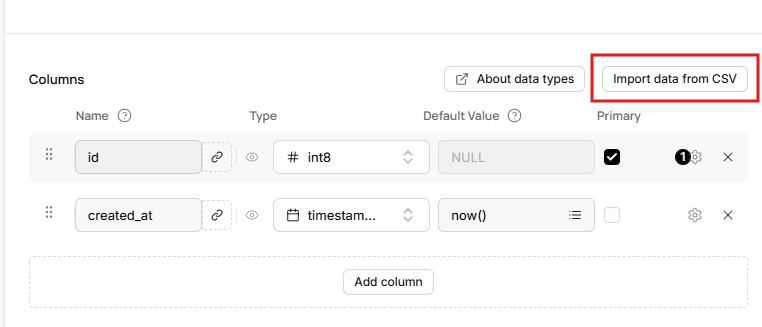

- Paste text (or Upload CSV) & save

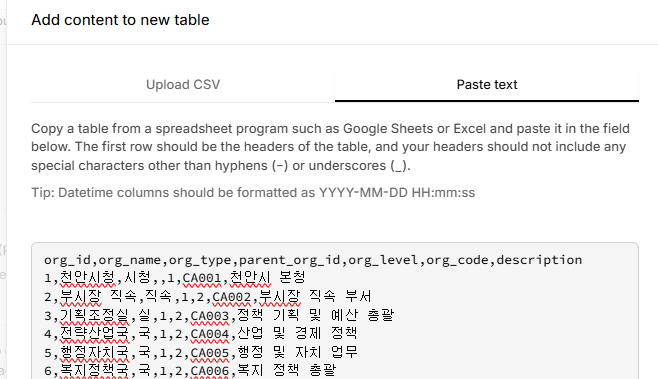

## 9. PostgreSQL 스키마 확인

In [50]:
print("=== PostgreSQL 스키마 ===")
print(db_pg.table_info)

print("\n" + "="*80 + "\n")

# 각 테이블 샘플 데이터
for table in ["organizations", "departments", "office_floors"]:
    try:
        print(f"{table} 테이블 샘플:")
        result = db_pg.run(f"SELECT * FROM {table} LIMIT 3")
        print(result)
        print()
    except Exception as e:
        print(f"✗ {table}: {e}\n")

=== PostgreSQL 스키마 ===

CREATE TABLE departments (
	dept_id BIGINT, 
	dept_name TEXT, 
	org_id BIGINT, 
	dept_code TEXT, 
	phone TEXT, 
	fax TEXT, 
	floor_location TEXT, 
	description TEXT
)

/*
3 rows from departments table:
dept_id	dept_name	org_id	dept_code	phone	fax	floor_location	description
101	홍보담당관	2	D101	041-521-2080	041-521-2089	본관 8층	홍보업무 총괄 및 보도자료 관리
102	감사관	2	D102	041-521-2040	041-521-2049	본관 4층	감사업무 총괄 및 청렴윤리 관리
103	스마트도시추진과	2	D103	041-521-2205	041-521-2209	본관 7층	스마트도시 정책 및 AI산업 추진
*/


CREATE TABLE office_floors (
	floor_id BIGINT, 
	building_name TEXT, 
	floor_number BIGINT, 
	floor_name TEXT, 
	main_departments TEXT, 
	facilities TEXT, 
	area_type TEXT
)

/*
3 rows from office_floors table:
floor_id	building_name	floor_number	floor_name	main_departments	facilities	area_type
1	천안시청 본관	1	본관 1층	민원여권과,노인복지과,허가과,복지정책과,장애인복지과,청년정책과	청사카페,민원실,대기공간	민원서비스층
2	천안시청 본관	2	본관 2층	미래전략과,일자리경제과,교육청소년과,청소행정과,K-컬처박람회추진과	도솔도서관	행정문화층
3	천안시청 본관	3	본관 3층	여성가족과,아동보육과	콜센터,대회의실,천안시정공무원노동조합	복지행정층


## 10. Text2SQL 테스트 - 답변 생성까지

In [51]:
from IPython.display import Markdown, display

questions = [
    "스마트정보과가 어디에 있나요?",
    "본관 1층에 위치한 부서들의 이름과 전화번호를 알려주세요",
    "문화체육국의 각 부서가 각각 몇층에 있나요?",
    "민원여권과 몇층에 있나요?",
    "041-521-2080 이 전화번호 어디인가요?",
]


for q in questions:
    print(f"\n{'='*80}")
    print(f"질문: {q}")
    print("=" * 80 + "\n")

    try:
        answer = query_database(q, db_pg)
        print("\n답변:")
        display(Markdown(answer))
    except Exception as e:
        print(f"오류: {e}")


질문: 스마트정보과가 어디에 있나요?

[1] SQL 생성 중...


    SELECT d.dept_name, d.floor_location, o.org_name
FROM departments d
LEFT JOIN organizations o ON d.org_id = o.org_id
WHERE d.dept_name LIKE '%스마트정보과%';

[2] SQL 실행 중...
    실행 완료

    결과: [('스마트정보과', '본관 4층', '행정자치국')]

[3] 답변 생성 중...

답변:


스마트정보과는 **본관 4층**에 있습니다.  
소속은 **행정자치국**입니다.


질문: 본관 1층에 위치한 부서들의 이름과 전화번호를 알려주세요

[1] SQL 생성 중...
    SELECT d.dept_name, d.phone
FROM departments d
JOIN office_floors f ON d.floor_location = f.floor_name
WHERE f.building_name = '천안시청 본관'
  AND f.floor_name = '본관 1층';

[2] SQL 실행 중...
    실행 완료

    결과: [('청년정책과', '041-521-2015'), ('허가과', '041-521-2500'), ('민원여권과', '041-521-2250'), ('복지정책과', '041-521-3430'), ('노인복지과', '041-521-2710'), ('장애인복지과', '041-521-2730')]

[3] 답변 생성 중...

답변:


본관 1층에 위치한 부서는 다음과 같습니다.

- 청년정책과: 041-521-2015
- 허가과: 041-521-2500
- 민원여권과: 041-521-2250
- 복지정책과: 041-521-3430
- 노인복지과: 041-521-2710
- 장애인복지과: 041-521-2730

...

문화체육국의 각 부서 위치는 다음과 같습니다.

- K-컬처박람회추진과: 본관 2층
- 관광과: 본관 11층
- 교육청소년과: 본관 2층
- 문화예술과: 본관 11층
- 체육진흥과: 본관 10층
- 축구종합센터건립추진과: 오룡홀 2층


질문: 민원여권과 몇층에 있나요?

[1] SQL 생성 중...
    SELECT floor_name
FROM office_floors
WHERE main_departments LIKE '%민원여권과%'
LIMIT 1;

[2] SQL 실행 중...
    실행 완료

    결과: [('본관 1층',)]

[3] 답변 생성 중...

답변:


민원여권과는 **본관 1층**에 있습니다.


질문: 041-521-2080 이 전화번호 어디인가요?

[1] SQL 생성 중...
    SELECT d.dept_name, d.description, d.floor_location, o.org_name
FROM departments d
LEFT JOIN organizations o ON d.org_id = o.org_id
WHERE d.phone = '041-521-2080';

[2] SQL 실행 중...
    실행 완료

    결과: [('홍보담당관', '홍보업무 총괄 및 보도자료 관리', '본관 8층', '부시장 직속')]

[3] 답변 생성 중...

답변:


041-521-2080은 **부시장 직속 홍보담당관** 전화번호입니다.  
- **부서명:** 홍보담당관  
- **설명:** 홍보업무 총괄 및 보도자료 관리  
- **위치:** 본관 8층

---

### 참고 자료

- [Langchain SQL Agent](https://docs.langchain.com/oss/python/langchain/sql-agent)
- [Langgraph SQL Agent](https://docs.langchain.com/oss/python/langgraph/sql-agent)